# Environment Setup

## PIP

In [28]:
%pip install colour
%pip install matplotlib
%pip install pandas
%pip install utm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Imports

In [29]:
import math
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import pandas as pd
import utm
from itertools import product
from collections import defaultdict
import io
import pandas as pd
import pickle
import matplotlib.patches as patches
from tkinter import filedialog
from colour import Color
import datetime


## Global Variables

In [30]:
dfArray  = []
# dataFolder = "/Users/flyingtopher/Developer/Code Citadel/School/2. Research/AviationThesis/Project_Data/Current Experiment/"
dataFolder = "../../Project_Data/Current Experiment/"
# print(dataFolder2)
# file = open(dataFolder)
LAT = 'Latitude'
LON = 'Longitude'
ALT = 'Altitude'
PITCH = 'Pitch'
ROLL = 'Roll'
DIST = '_dist,___ft'
LATDEV = 'latdev'
LANDED = 'landed'
IDEAL_ALT = 'ideal_alt'
ZERO = 'zero'

## Functions

In [31]:
def to_point(lat, lon):
    x, y, _, _ = utm.from_latlon(lat, lon)
    return 3.28084 * np.array([x, y])

def get_distance(pt1, pt2):
  A = (pt2 - pt1)
  return A[1]
  # return np.linalg.norm(pt2 - pt1)

RUNWAY_START = to_point(39.895791, -104.696085)
RUNWAY_END = to_point(39.851898, -104.6966)
def get_lateral_deviation(pt):
    p1 = RUNWAY_START
    p2 = RUNWAY_END
    return np.cross(p2-p1, p1-pt) / np.linalg.norm(p2 - p1)

def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


def drawAllowed(input):
  allowedArray = [1,5,10]
  # allowedArray = [1,2,3,4,5,6,7,8,9,10];
  allowed = False
  for x in allowedArray:
    if(input == x):
      allowed = True
      return allowed
  return allowed

# Data Ingestion

In [19]:
for x in range (1,2):
    experimentNum = x
    experimentFile =  str(experimentNum) + "_1--Turbulence Experiments" ".csv"
    currentExperiment = dataFolder + experimentFile
    # currentExperiment = "/content/Data.txt"
    df = pd.read_csv(currentExperiment)
    df.columns = df.columns.str.replace(' ', '')
    df = df.dropna()

    pts = df.apply(lambda row: to_point(row[LAT], row[LON]), axis=1)
    dist = df.apply(lambda row: get_distance(RUNWAY_START,to_point(row[LAT],row[LON])), axis=1)
    df[DIST] = dist

    df[LANDED] = df[ALT] < 0.5
    # df.columns
    # color = np.random.randint(0, 3, size = n)
    df[LATDEV] = [get_lateral_deviation(pt) for pt in pts]
    df[LANDED] = df[ALT] < 0.5
    df[LANDED]
    dfArray.append(df)
  # else:
  #   # dfArray.append()
len(dfArray)
# dfArray[0].head()

#Save so we dont have to runthis again.....
with open('dataFrameArray.pkl', 'wb') as file:
  pickle.dump(dfArray, file)

/var/folders/mg/0046pj397qn7zqxn7sxp4b_w0000gn/T/ipykernel_92494/3280187756.py:15: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return np.cross(p2-p1, p1-pt) / np.linalg.norm(p2 - p1)


# Single Analysis

## Load Data from Pickle

In [35]:
with open('dataFrameArray.pkl', 'rb') as file:
  # dfArray = pickle.Unpickler(file)
  dfArray = pickle.load(file)

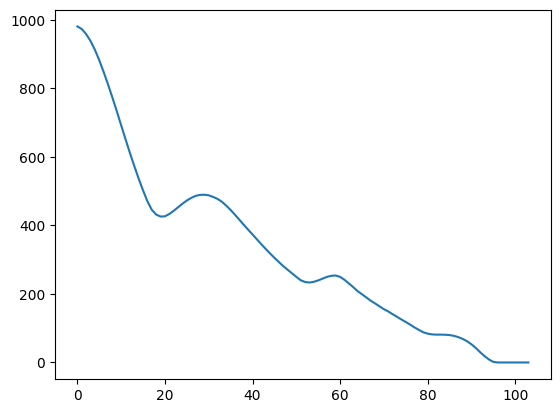

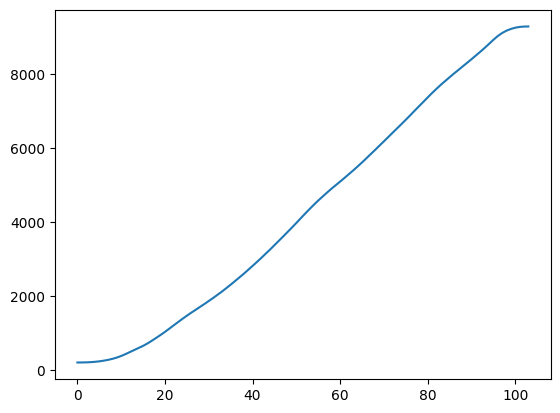

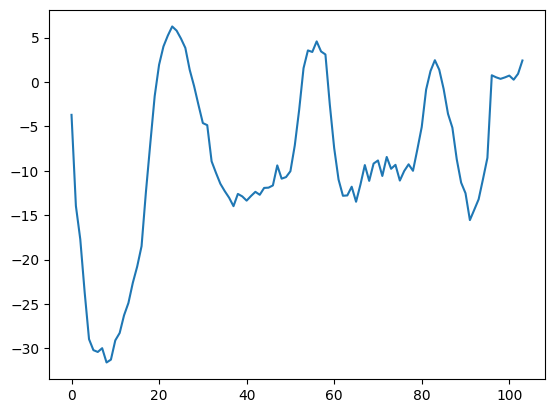

In [45]:
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
plt.plot(dfArray[0][ALT])
plt.savefig('../Figures/Model/Single_Batch/Altitude_' + timestamp)
plt.show()

plt.plot(dfArray[0][LATDEV])
plt.savefig('../Figures/Model/Single_Batch/Lateral_Deviation_'+ timestamp)
plt.show()

plt.plot(dfArray[0][PITCH])
plt.savefig('../Figures/Model/Single_Batch/Pitch_'+ timestamp)
plt.show()

# Batch Analysis